In [10]:
import ROOT

import genie_loader
from importlib import reload
reload(genie_loader)
from genie_loader import *

In [7]:
det_width=39 #m
det_height=15.8 #m
cut_extend=1 #m

det_half_width = 19.5

In [35]:
filename = "/home/tomren/geant_projects/genie/Generator-R-3_04_00/gntp.1.gtrac.root"

In [87]:

tfile=ROOT.TFile(filename)
tree_name = tfile.GetListOfKeys()[0].GetName()
Tree = tfile.Get(tree_name)
entries = Tree.GetEntries()
branches = [Tree.GetListOfBranches()[i].GetName() for i in range(len(Tree.GetListOfBranches()))]
tfile.ls()
print(entries, branches)


vertex_selected={}
for i in range(entries):
    Tree.GetEntry(i)   

    # Get the vertex location
    vertex=list(Tree.EvtVtx) # (x, y, z, t) of vertex (in SI)
    x,y,z,t = vertex

    # Only select those within the detector volume plus a little edge
    if (abs(x)<det_width/2+cut_extend)  &  (abs(y)<det_width/2+cut_extend)  & (-z>-cut_extend) & (-z<det_height+cut_extend):
        # pdgs = list(Tree.StdHepPdg)
        # x4s = extract_array(Tree.StdHepX4, n=4) # (x, y, z, t) in hit nucleus rest frame (in fm)
        # p4s = extract_array(Tree.StdHepP4, n=4) # (px, py, pz, E) in LAB frame in [GeV]
        
        # Only read the final state particles in this event
        p4s, pdgs = get_final(Tree)           
        
        
        # Get event info
        evtcode=str(Tree.EvtCode).split(";") # Example: 'nu:14;tgt:1000080160;N:2112;proc:Weak[CC],QES;'
        parent_pdg=int(evtcode[0].split(":")[1])

        # add back the detector offset
        # xx,yy,zz=y*1000, (-z+85.47)*1000, (x+90)*1000 # Convert to CMS coordinate (wrong)
        xx,yy,zz=(x+90)*1000, y*1000, z*1000
        vertex_selected[i]=[[parent_pdg, xx,yy,zz, 0,0,0, 0]]
        for iparticle in range(len(p4s)):
            p4=p4s[iparticle]
            pdg=pdgs[iparticle]
            # Remove the pdgs of Nuclear codes
            if abs(pdg)<10000:
                vertex_selected[i].append([pdg, xx,yy,zz, p4[0]*1000, p4[1]*1000, p4[2]*1000, 0])

872 ['EvtFlags', 'EvtCode', 'EvtNum', 'EvtXSec', 'EvtDXSec', 'EvtKPS', 'EvtWght', 'EvtProb', 'EvtVtx', 'StdHepN', 'StdHepPdg', 'StdHepStatus', 'StdHepRescat', 'StdHepX4', 'StdHepP4', 'StdHepPolz', 'StdHepFd', 'StdHepLd', 'StdHepFm', 'StdHepLm']
TFile**		/home/tomren/geant_projects/genie/Generator-R-3_04_00/gntp.1.gtrac.root	
 TFile*		/home/tomren/geant_projects/genie/Generator-R-3_04_00/gntp.1.gtrac.root	
  OBJ: TTree	gRooTracker	GENIE event tree rootracker format : 0 at: 0x63e25d214690
  KEY: TTree	gRooTracker;1	GENIE event tree rootracker format


In [88]:
vertices=[]
for i in tqdm(range(entries)):
    Tree.GetEntry(i)    
    vertices.append(list(Tree.EvtVtx))
vertices=np.array(vertices)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 872/872 [00:00<00:00, 39133.67it/s]


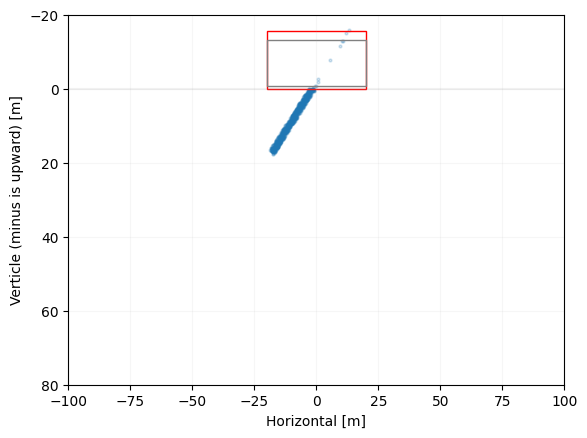

In [89]:
plt.scatter(-vertices[:,0], vertices[:,2], s=4, alpha=0.2)
plt.gca().add_patch(patch.Rectangle((-20,-det_height), 40,det_height, edgecolor='r', facecolor='none'))
plt.gca().add_patch(patch.Rectangle((-20,-det_height+2.4), 40,det_height-3.2, edgecolor='grey', facecolor='none'))
plt.xlim(-100,100)
plt.ylim(-20,80)
plt.gca().invert_yaxis()
plt.axhline(0,color="grey", alpha=0.1)
plt.xlabel("Horizontal [m]")
plt.ylabel("Verticle (minus is upward) [m]")
plt.grid(alpha=0.1)
# plt.axhline(-85.47)